## Feature Engineering of the IBM Dataset

In [39]:
import pandas as pd

df = pd.read_csv('../datasets/processed/telco_customer_churn_clean.csv')
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


## Feature 1 : Tenure Bucket

- from eda we know that low tenure means high churn and long tenure means low churn
- this means theres likely a non linear relationship
- we'll create three buckets: low, medium, high

In [40]:

def tenure_bucket(tenure):
    if tenure <= 12:
        return 'low'
    elif tenure <= 48:
        return 'medium'
    else:
        return 'high'
    
    
df['Tenure Bucket'] = df['Tenure Months'].apply(tenure_bucket)
df.head()


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Tenure Bucket
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,low
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,low
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,low
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,medium
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,high


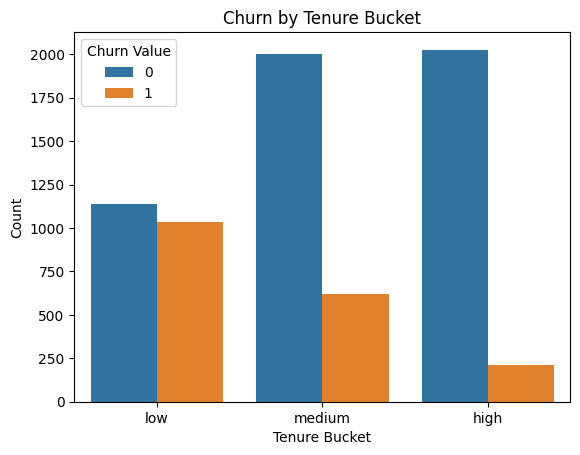

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.crosstab(df["Tenure Bucket"], df["Churn Value"], normalize="index")

sns.countplot(x="Tenure Bucket", hue="Churn Value", data=df)
plt.title("Churn by Tenure Bucket")
plt.xlabel("Tenure Bucket")
plt.ylabel("Count")
plt.show()


## Feature 2: Service Count

- customers that are more integrated into the ecosystem will churn less
- we can count how many add on servies they use

In [42]:
service_cols = ["Online Security", "Online Backup", "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"]

In [43]:
for col in service_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0, "No internet service": 0})

In [44]:
df["Total Services"] = df[service_cols].sum(axis=1).astype(int)
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Tenure Bucket,Total Services
0,Male,No,No,No,2,Yes,No,DSL,1,1,...,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,1,low,2
1,Female,No,No,Yes,2,Yes,No,Fiber optic,0,0,...,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,1,low,0
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,0,0,...,1,1,Month-to-month,Yes,Electronic check,99.65,820.50,1,low,3
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,0,0,...,1,1,Month-to-month,Yes,Electronic check,104.80,3046.05,1,medium,4
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,0,1,...,1,1,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,high,4


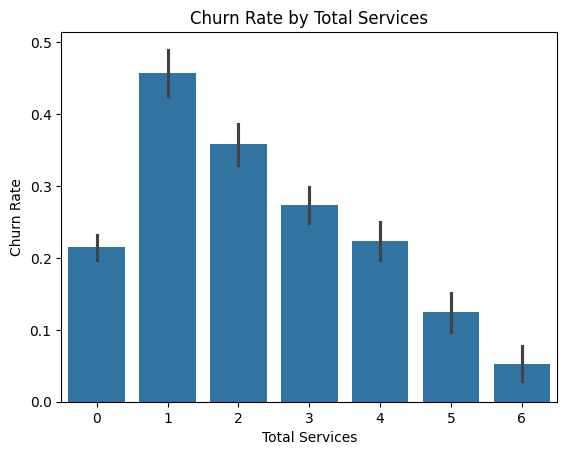

In [45]:
df.groupby("Total Services")["Churn Value"].mean()

sns.barplot(x="Total Services", y="Churn Value", data=df)
plt.title("Churn Rate by Total Services")
plt.xlabel("Total Services")
plt.ylabel("Churn Rate")
plt.show()


## Feature 3: Is Month-to-Month (Binary Feature)

- month to month customers have a higher churn

In [46]:
df["Is Month-to-Month"] = df["Contract"].apply(lambda x: 1 if x == "Month-to-month" else 0)
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Tenure Bucket,Total Services,Is Month-to-Month
0,Male,No,No,No,2,Yes,No,DSL,1,1,...,0,Month-to-month,Yes,Mailed check,53.85,108.15,1,low,2,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,0,0,...,0,Month-to-month,Yes,Electronic check,70.70,151.65,1,low,0,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,0,0,...,1,Month-to-month,Yes,Electronic check,99.65,820.50,1,low,3,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,0,0,...,1,Month-to-month,Yes,Electronic check,104.80,3046.05,1,medium,4,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,0,1,...,1,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,high,4,1


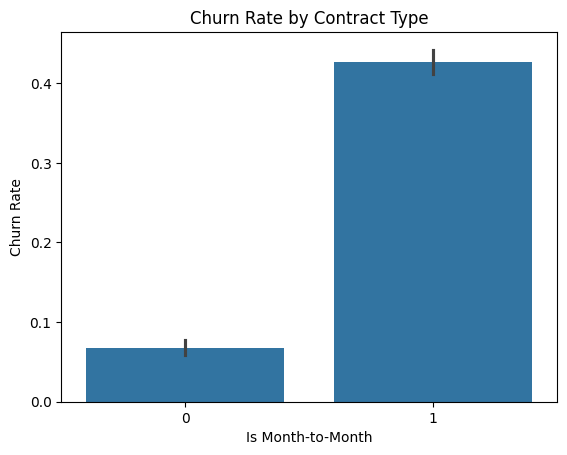

In [47]:
df.groupby("Is Month-to-Month")["Churn Value"].mean()

sns.barplot(x="Is Month-to-Month", y="Churn Value", data=df)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Is Month-to-Month")
plt.ylabel("Churn Rate")
plt.show()

## Feature 4: High Monthly Charges Flag 

- churn increases at higher monthly charges 

In [48]:
threshold = df["Monthly Charges"].median()
df["High Monthly Charges"] = df["Monthly Charges"].apply(lambda x: 1 if x > threshold else 0)
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Tenure Bucket,Total Services,Is Month-to-Month,High Monthly Charges
0,Male,No,No,No,2,Yes,No,DSL,1,1,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,low,2,1,0
1,Female,No,No,Yes,2,Yes,No,Fiber optic,0,0,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,low,0,1,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,0,0,...,Month-to-month,Yes,Electronic check,99.65,820.50,1,low,3,1,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,0,0,...,Month-to-month,Yes,Electronic check,104.80,3046.05,1,medium,4,1,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,0,1,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,high,4,1,1


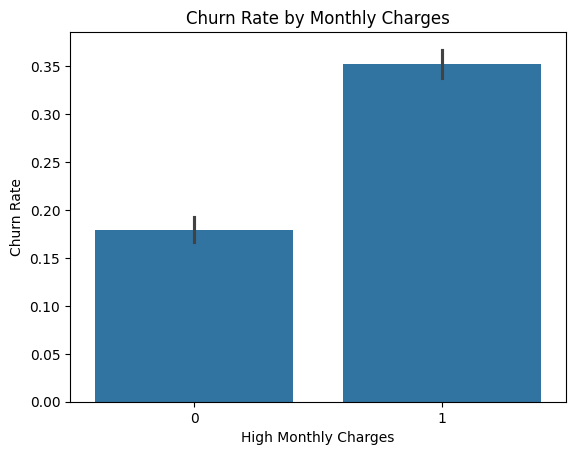

In [49]:
df.groupby("High Monthly Charges")["Churn Value"].mean()

sns.barplot(x="High Monthly Charges", y="Churn Value", data=df)
plt.title("Churn Rate by Monthly Charges")
plt.xlabel("High Monthly Charges")
plt.ylabel("Churn Rate")
plt.show()

## Feature 5: Has Protection 

- we can combine three features here: Online Security, Tech Support and Device Protection

In [50]:
df["Has Protection"] = ((df["Online Security"] == 1) | (df["Device Protection"] == 1) | (df["Tech Support"] == 1)).astype(int)
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Tenure Bucket,Total Services,Is Month-to-Month,High Monthly Charges,Has Protection
0,Male,No,No,No,2,Yes,No,DSL,1,1,...,Yes,Mailed check,53.85,108.15,1,low,2,1,0,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,0,0,...,Yes,Electronic check,70.70,151.65,1,low,0,1,1,0
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,0,0,...,Yes,Electronic check,99.65,820.50,1,low,3,1,1,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,0,0,...,Yes,Electronic check,104.80,3046.05,1,medium,4,1,1,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,0,1,...,Yes,Bank transfer (automatic),103.70,5036.30,1,high,4,1,1,1


## Dropping Redundant Features
- we can drop Total Charges since it's highly correlated with Tenure Months and Monthly Charges
- we can drop Contract since we have Is Month-to-Month
- we can crop Has Protection (it didnt show a strong relationship with churn and is redundant with the individual protection services)

In [51]:
df.drop(columns=["Total Charges", "Contract", "Has Protection"], inplace=True)
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Paperless Billing,Payment Method,Monthly Charges,Churn Value,Tenure Bucket,Total Services,Is Month-to-Month,High Monthly Charges
0,Male,No,No,No,2,Yes,No,DSL,1,1,...,0,0,Yes,Mailed check,53.85,1,low,2,1,0
1,Female,No,No,Yes,2,Yes,No,Fiber optic,0,0,...,0,0,Yes,Electronic check,70.70,1,low,0,1,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,0,0,...,1,1,Yes,Electronic check,99.65,1,low,3,1,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,0,0,...,1,1,Yes,Electronic check,104.80,1,medium,4,1,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,0,1,...,1,1,Yes,Bank transfer (automatic),103.70,1,high,4,1,1


In [52]:
df.shape

(7032, 22)

In [53]:
df.isnull().sum()

Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Churn Value             0
Tenure Bucket           0
Total Services          0
Is Month-to-Month       0
High Monthly Charges    0
dtype: int64

In [54]:
df.dtypes

Gender                      str
Senior Citizen              str
Partner                     str
Dependents                  str
Tenure Months             int64
Phone Service               str
Multiple Lines              str
Internet Service            str
Online Security           int64
Online Backup             int64
Device Protection         int64
Tech Support              int64
Streaming TV              int64
Streaming Movies          int64
Paperless Billing           str
Payment Method              str
Monthly Charges         float64
Churn Value               int64
Tenure Bucket               str
Total Services            int64
Is Month-to-Month         int64
High Monthly Charges      int64
dtype: object

In [55]:
df.to_csv("../datasets/processed/feature_engineered_telco.csv", index=False)